# State Model (2022)
I aggregate chargers to state level (cap at Dec 31, 2022) and merge with 2022 ACS. More samples than NJ counties, so the model is meaningful. I keep linear as baseline and RF as a check.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

base = Path('..')
state = pd.read_csv(base/'data/processed/state_features_2022.csv')
print('States', len(state))


States 40


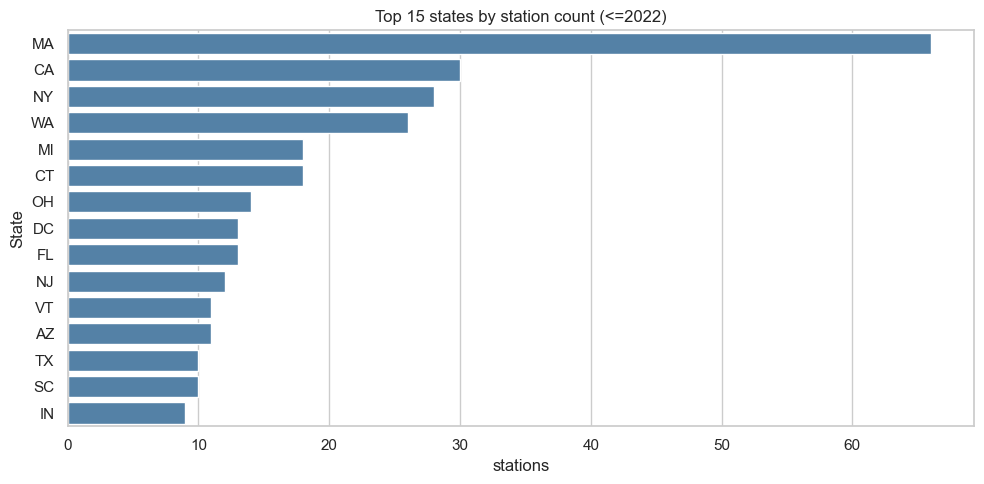

In [2]:
sns.set(style='whitegrid')
plt.figure(figsize=(10,5))
sns.barplot(data=state.sort_values('stations', ascending=False).head(15), x='stations', y='State', color='steelblue')
plt.title('Top 15 states by station count (<=2022)')
plt.tight_layout()
plt.show()

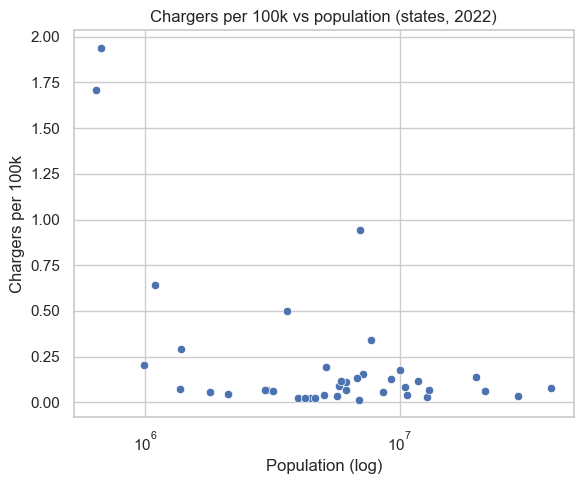

In [3]:
plt.figure(figsize=(6,5))
sns.scatterplot(data=state, x='population', y='chargers_per_100k')
plt.xscale('log')
plt.xlabel('Population (log)')
plt.ylabel('Chargers per 100k')
plt.title('Chargers per 100k vs population (states, 2022)')
plt.tight_layout()
plt.show()

In [4]:
feature_cols = ['population','median_household_income','renter_occupied_pct','mean_travel_time_to_work_minutes','chargers_per_100k']
print(state[feature_cols].corr())

                                  population  median_household_income  \
population                          1.000000                 0.997053   
median_household_income             0.997053                 1.000000   
renter_occupied_pct                 0.983498                 0.992781   
mean_travel_time_to_work_minutes   -0.035503                -0.030281   
chargers_per_100k                  -0.259414                -0.271217   

                                  renter_occupied_pct  \
population                                   0.983498   
median_household_income                      0.992781   
renter_occupied_pct                          1.000000   
mean_travel_time_to_work_minutes            -0.051994   
chargers_per_100k                           -0.300992   

                                  mean_travel_time_to_work_minutes  \
population                                               -0.035503   
median_household_income                                  -0.030281   
renter_o

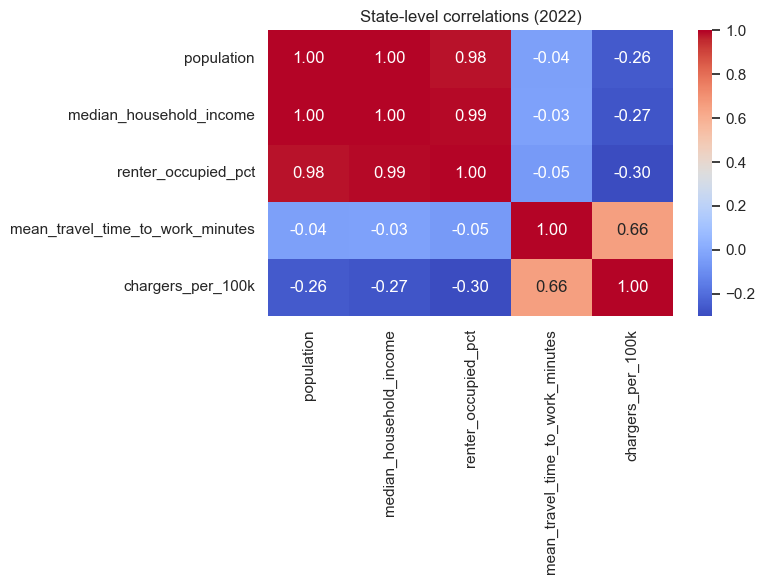

In [7]:
plt.figure(figsize=(8,6))
sns.heatmap(state[feature_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('State-level correlations (2022)')
plt.tight_layout()
plt.show()


In [6]:
features = ['population','median_household_income','renter_occupied_pct','mean_travel_time_to_work_minutes']
X = state[features]
y = state['chargers_per_100k']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
lin = LinearRegression().fit(X_train, y_train)
pred_lin = lin.predict(X_test)
rmse_lin = mean_squared_error(y_test, pred_lin)**0.5
r2_lin = r2_score(y_test, pred_lin)
rf = RandomForestRegressor(random_state=42, n_estimators=300).fit(X_train, y_train)
pred_rf = rf.predict(X_test)
rmse_rf = mean_squared_error(y_test, pred_rf)**0.5
r2_rf = r2_score(y_test, pred_rf)
print({'linear_rmse': rmse_lin, 'linear_r2': r2_lin, 'rf_rmse': rmse_rf, 'rf_r2': r2_rf})


{'linear_rmse': 0.3170321433324293, 'linear_r2': 0.6572734275322103, 'rf_rmse': 0.32644346823639936, 'rf_r2': 0.6366232379993603}


State run summary: Linear RMSE ~0.317, R² ~0.657. RF RMSE ~0.326, R² ~0.638. Linear slightly better here. Using 2022 alignment fixed the earlier NJ sparsity issue.